In [1]:
# test spectogram block
import torch
from torch.utils.data import DataLoader


from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.models.blocks.spectrogram import SpectrogramBlock
from thesis_project.utils.paths import get_data_dir

data_dir = get_data_dir()
dataset = SpeechCommandsGoogle(root=str(data_dir), subset="training", download=True)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

# inspect a single item
waveform, label, metadata = dataset[110]

spec_complex = SpectrogramBlock(sample_rate=16000, power=None, logarithm=False)
spec_magnitude = SpectrogramBlock(sample_rate=16000, power=1.0, logarithm=False)
spec_DB = SpectrogramBlock(sample_rate=16000, power=1.0, logarithm=True)

sample = {}
sample["raw"] = waveform.unsqueeze(0)  # add batch dim
sample["complex"] = spec_complex(sample["raw"])
sample["mag"] = spec_magnitude(sample["raw"])
sample["decibel"] = spec_DB(sample["raw"])
sample["phase"] = torch.angle(sample["complex"])
sample["real"] = sample["complex"].real
sample["imag"] = sample["complex"].imag


/Users/christoffer/Documents/Thesis/thesis_project/.venv/lib/python3.12/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [4]:
mag.shape

(257, 63)

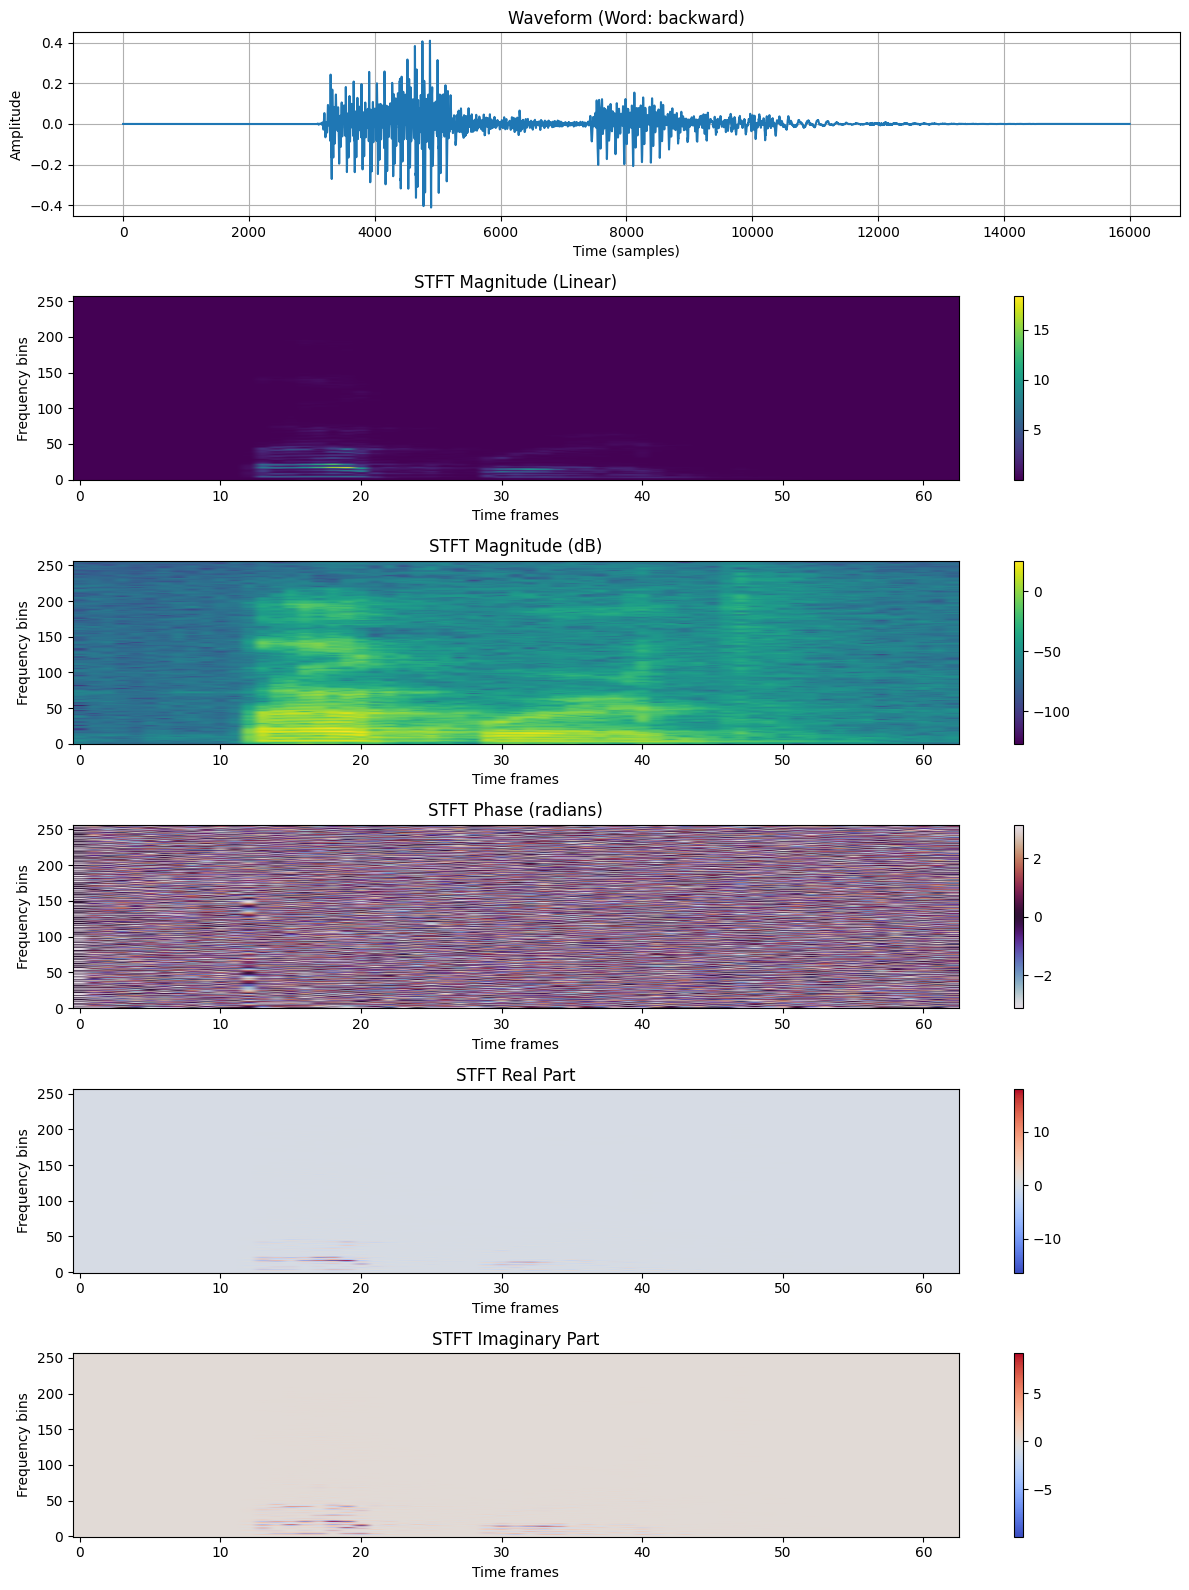

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random, os

waveform = sample["raw"].squeeze().numpy()
mag = sample["mag"].squeeze().numpy()
decibel = sample["decibel"].squeeze().numpy()
phase = sample["phase"].squeeze().numpy()
real = sample["real"].squeeze().numpy()
imag = sample["imag"].squeeze().numpy()


# Plot everything
fig, axes = plt.subplots(6, 1, figsize=(12, 16))

# Raw waveform
axes[0].plot(waveform)
axes[0].set_title(f"Waveform (Word: {metadata['label']})")
axes[0].set_xlabel("Time (samples)")
axes[0].set_ylabel("Amplitude")
axes[0].grid()

# Magnitude spectrogram (linear scale)
im0 = axes[1].imshow(mag, aspect="auto", origin="lower")
axes[1].set_title("STFT Magnitude (Linear)")
axes[1].set_xlabel("Time frames")
axes[1].set_ylabel("Frequency bins")
fig.colorbar(im0, ax=axes[1])

# Magnitude spectrogram (dB scale)
im1 = axes[2].imshow(decibel, aspect="auto", origin="lower")
axes[2].set_title("STFT Magnitude (dB)")
axes[2].set_xlabel("Time frames")
axes[2].set_ylabel("Frequency bins")
fig.colorbar(im1, ax=axes[2])

# Phase spectrogram
im2 = axes[3].imshow(phase, aspect="auto", origin="lower", cmap="twilight")
axes[3].set_title("STFT Phase (radians)")
axes[3].set_xlabel("Time frames")
axes[3].set_ylabel("Frequency bins")
fig.colorbar(im2, ax=axes[3])

# Real part
im3 = axes[4].imshow(real, aspect="auto", origin="lower", cmap="coolwarm")
axes[4].set_title("STFT Real Part")
axes[4].set_xlabel("Time frames")
axes[4].set_ylabel("Frequency bins")
fig.colorbar(im3, ax=axes[4])

# Imaginary part
im4 = axes[5].imshow(imag, aspect="auto", origin="lower", cmap="coolwarm")
axes[5].set_title("STFT Imaginary Part")
axes[5].set_xlabel("Time frames")
axes[5].set_ylabel("Frequency bins")
fig.colorbar(im4, ax=axes[5])

plt.tight_layout()
plt.show()
